# Разработка A/B-тестирования и анализ результатов

**Автор проекта**: Казанцев Павел Павлович

## Введение

Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

**Задача**: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## План разработки и анализа результатов A/B теста

1. Работа с историческими данными (EDA)
- Загрузка исторический данных 
- Знакомство с данными
- Анализ числа регистраций
- Анализ числа просмотренных страниц 
- Доля пользователей, просмотревших более четырех страниц (успешная сессия)
2. Подготовка к тесту
- Расчет размера выборки 
- Расчет длительность А/В теста
3. Мониторинг А/В теста
- Проверка распределения пользователей
- Проверка пересечений пользователей
- Равномерность распределения пользователей по устройствам
- Равномерность распределения пользователей по регионам
- Вывод после проверки A/B теста
4. Проверка результатов A/B теста 
- Получение результатов теста и подсчет основной метрики
- Формулировка нулевой и альтернативной гипотезы
- Сравнение доли успешных первых сессий
- Статистическая значимость изменения ключевой метрики
- Расчет и проверка стат. значимости прокси-метрик
- Проверка на соответсвтия размера выборки
- Вывод по результатам A/B теста 

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
# Установка библиотеки для форматирования кода
%pip install jupyter_black

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jupyter_black
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import ttest_ind

jupyter_black.load()

In [3]:
# Загрузка датасета с историческими данными о сессиях пользователей
sessions_history = pd.read_csv(
    "https://code.s3.yandex.net/datasets/sessions_project_history.csv",
    parse_dates=["session_date", "session_start_ts", "install_date"],
)

In [4]:
# Просмотр первых записей
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [5]:
# Просмотр информации о датасете
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            435924 non-null  object        
 1   session_id         435924 non-null  object        
 2   session_date       435924 non-null  datetime64[ns]
 3   session_start_ts   435924 non-null  datetime64[ns]
 4   install_date       435924 non-null  datetime64[ns]
 5   session_number     435924 non-null  int64         
 6   registration_flag  435924 non-null  int64         
 7   page_counter       435924 non-null  int64         
 8   region             435924 non-null  object        
 9   device             435924 non-null  object        
dtypes: datetime64[ns](3), int64(3), object(4)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными

- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [6]:
# Подсчет сессий для каждого пользователя
df_sessions = (
    sessions_history.groupby("user_id", as_index=False)["session_id"]
    .nunique()
    .sort_values(by="session_id", ascending=False)
)

# Топ-пользователь по количеству уникальных сессий
top_user = df_sessions[df_sessions["session_id"] == max(df_sessions["session_id"])][
    "user_id"
].tolist()

# Данные пользователей с наибольшим кол-во сессий
sessions_history[sessions_history["user_id"].isin(top_user[0:1])]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [7]:
# Поиск первой даты для каждого пользователя с фактом регистрации
date_registration = (
    sessions_history[sessions_history["registration_flag"] == 1]
    .groupby("user_id")["session_date"]
    .min()
)

# Новый столбец с датой регистрациий, подтягиваем значения по индексу date_registration - user_id
sessions_history["date_registration"] = sessions_history["user_id"].map(
    date_registration
)

# Маска для регистрирующихся пользователей
new_users_mask = (sessions_history["registration_flag"] == 1) & (
    sessions_history["session_date"] == sessions_history["date_registration"]
)

# Расчет кол-ва зарегистрированных уникальных пользователей для каждого дня наблюдения
registration_users = (
    sessions_history[new_users_mask].groupby("session_date")["user_id"].nunique()
)

# Расчет кол-ва уникальных пользователей для каждого дня наблюдения
all_users = sessions_history.groupby("session_date")["user_id"].nunique()

# Замена индексов (дат) и значений NaN
registration_users = registration_users.reindex(all_users.index, fill_value=0)

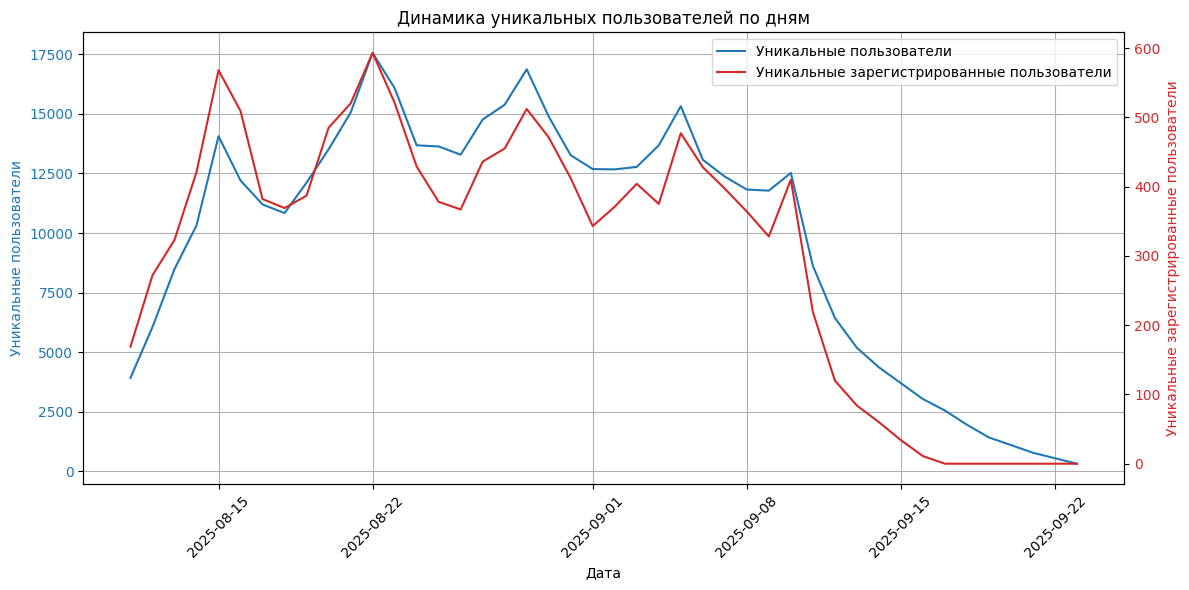

In [8]:
# График кол-ва уникальных пользователей и зарегистрировавшихся пользователей по дням
fig, ax1 = plt.subplots(figsize=(12, 6))

# Первая ось Y - все пользователи
ax1.plot(
    all_users.index,
    all_users.values,
    color="tab:blue",
    label="Уникальные пользователи",
)
ax1.set_xlabel("Дата")
ax1.set_ylabel("Уникальные пользователи", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.tick_params(axis="x", labelrotation=45)
ax1.grid(True)

# Вторая ось Y - зарегистрированные пользователи (общая ось X)
ax2 = ax1.twinx()
ax2.plot(
    registration_users.index,
    registration_users.values,
    color="tab:red",
    label="Уникальные зарегистрированные пользователи",
)
ax2.set_ylabel("Уникальные зарегистрированные пользователи", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Общая легенда (т.к. у каждой оси своя)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Динамика уникальных пользователей по дням")
plt.tight_layout()
plt.show()

In [9]:
all_users

session_date
2025-08-11     3919
2025-08-12     6056
2025-08-13     8489
2025-08-14    10321
2025-08-15    14065
2025-08-16    12205
2025-08-17    11200
2025-08-18    10839
2025-08-19    12118
2025-08-20    13514
2025-08-21    15051
2025-08-22    17563
2025-08-23    16082
2025-08-24    13683
2025-08-25    13635
2025-08-26    13289
2025-08-27    14766
2025-08-28    15388
2025-08-29    16873
2025-08-30    14891
2025-08-31    13266
2025-09-01    12685
2025-09-02    12672
2025-09-03    12777
2025-09-04    13683
2025-09-05    15324
2025-09-06    13078
2025-09-07    12367
2025-09-08    11826
2025-09-09    11780
2025-09-10    12526
2025-09-11     8623
2025-09-12     6436
2025-09-13     5183
2025-09-14     4364
2025-09-15     3698
2025-09-16     3032
2025-09-17     2548
2025-09-18     1952
2025-09-19     1418
2025-09-20     1100
2025-09-21      776
2025-09-22      546
2025-09-23      317
Name: user_id, dtype: int64

In [10]:
registration_users

session_date
2025-08-11    169
2025-08-12    272
2025-08-13    323
2025-08-14    421
2025-08-15    568
2025-08-16    509
2025-08-17    382
2025-08-18    369
2025-08-19    387
2025-08-20    485
2025-08-21    520
2025-08-22    593
2025-08-23    521
2025-08-24    429
2025-08-25    378
2025-08-26    367
2025-08-27    436
2025-08-28    455
2025-08-29    512
2025-08-30    471
2025-08-31    412
2025-09-01    343
2025-09-02    371
2025-09-03    404
2025-09-04    375
2025-09-05    477
2025-09-06    428
2025-09-07    397
2025-09-08    364
2025-09-09    328
2025-09-10    410
2025-09-11    219
2025-09-12    120
2025-09-13     84
2025-09-14     60
2025-09-15     34
2025-09-16     11
2025-09-17      0
2025-09-18      0
2025-09-19      0
2025-09-20      0
2025-09-21      0
2025-09-22      0
2025-09-23      0
Name: user_id, dtype: int64

Количество уникальных пользователей имеет схожую тенденцию с количеством регистрирующихся пользователей по дням. Начиная с 10 сентября, оба показателя стремительно снижаются. 

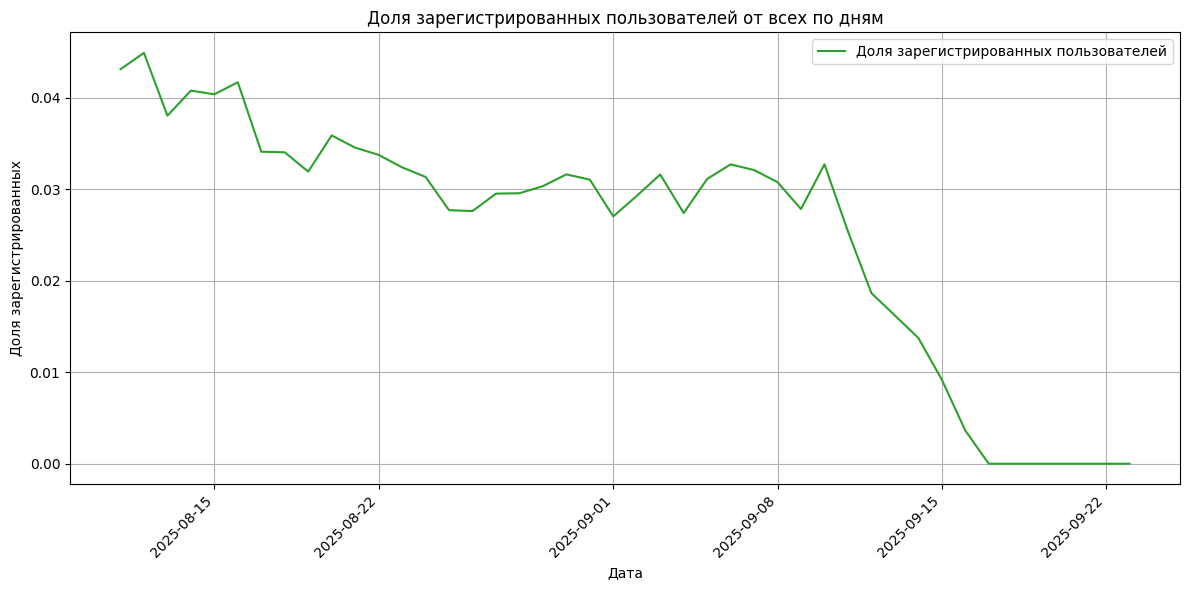

In [11]:
# Расчет доли зарегистрировавшихся пользователей от общего кол-ва
share_reg_users = registration_users / all_users

# График доли зарегистрировавшихся пользователей от общего кол-ва
fig2, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    share_reg_users.index,
    share_reg_users.values,
    color="tab:green",
    label="Доля зарегистрированных пользователей",
)
ax.set_xlabel("Дата")
ax.set_ylabel("Доля зарегистрированных")
ax.set_title("Доля зарегистрированных пользователей от всех по дням")
ax.grid(True)
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
round(share_reg_users, 3)

session_date
2025-08-11    0.043
2025-08-12    0.045
2025-08-13    0.038
2025-08-14    0.041
2025-08-15    0.040
2025-08-16    0.042
2025-08-17    0.034
2025-08-18    0.034
2025-08-19    0.032
2025-08-20    0.036
2025-08-21    0.035
2025-08-22    0.034
2025-08-23    0.032
2025-08-24    0.031
2025-08-25    0.028
2025-08-26    0.028
2025-08-27    0.030
2025-08-28    0.030
2025-08-29    0.030
2025-08-30    0.032
2025-08-31    0.031
2025-09-01    0.027
2025-09-02    0.029
2025-09-03    0.032
2025-09-04    0.027
2025-09-05    0.031
2025-09-06    0.033
2025-09-07    0.032
2025-09-08    0.031
2025-09-09    0.028
2025-09-10    0.033
2025-09-11    0.025
2025-09-12    0.019
2025-09-13    0.016
2025-09-14    0.014
2025-09-15    0.009
2025-09-16    0.004
2025-09-17    0.000
2025-09-18    0.000
2025-09-19    0.000
2025-09-20    0.000
2025-09-21    0.000
2025-09-22    0.000
2025-09-23    0.000
Name: user_id, dtype: float64

Наблюдается нисходящая тенденция доли зарегистрировавшихся пользователей. С 17 по 23 сентября новых регистраций не зафиксировано. 

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Рассчитаем количество первых сессий для каждого значения количества просмотренных страниц.

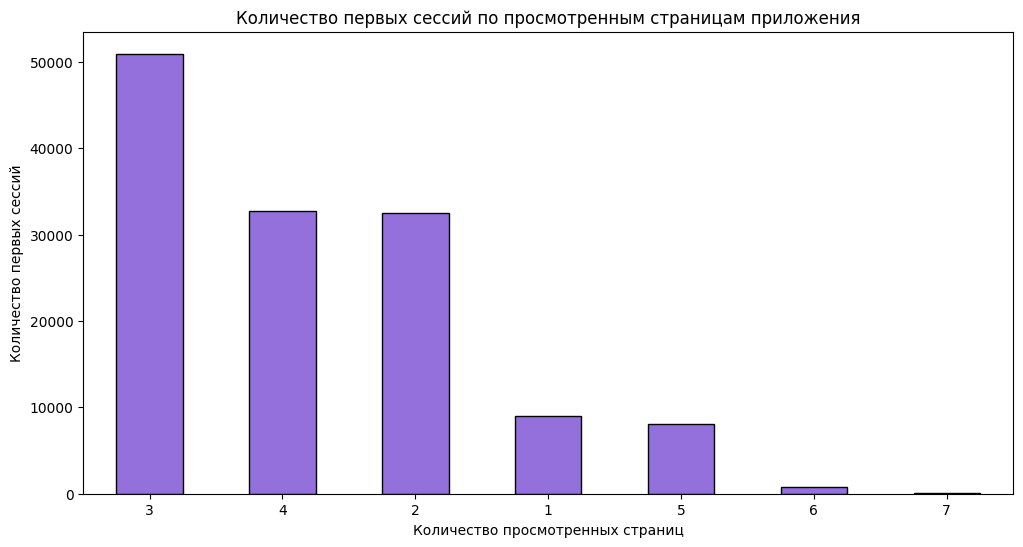

page_counter
3    50939
4    32739
2    32494
1     8978
5     8075
6      777
7       37
Name: session_number, dtype: int64

In [13]:
# Группировка кол-ва первых сессий по просмотренным страницам
page_session = (
    sessions_history[sessions_history["session_number"] == 1]
    .groupby("page_counter")["session_number"]
    .sum()
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
page_session.plot(kind="bar", color="mediumpurple", edgecolor="black", rot=0)
plt.xlabel("Количество просмотренных страниц")
plt.ylabel("Количество первых сессий")
plt.title("Количество первых сессий по просмотренным страницам приложения")
plt.show()

display(page_session)

При первой сессии пользователи **чаще всего смотрят 2-4 страницы (32494 - 50939)**. Реже ограничиваются просмотром 1 страницы приложения (8978) и совсем редко смотрят больше 5 страниц 

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

In [14]:
# Новый столбец - бинарное обозначение (1 - просмотрено 4 и более страниц, 0 - было просмотрено меньше)
sessions_history["good_session"] = (sessions_history["page_counter"] >= 4).astype(int)

first_session = (
    sessions_history[sessions_history["session_number"] == 1]
    .groupby("session_date")["session_number"]
    .sum()
)
good_first_session = (
    sessions_history[sessions_history["session_number"] == 1]
    .groupby("session_date")["good_session"]
    .sum()
)

share_good_session = good_first_session / first_session

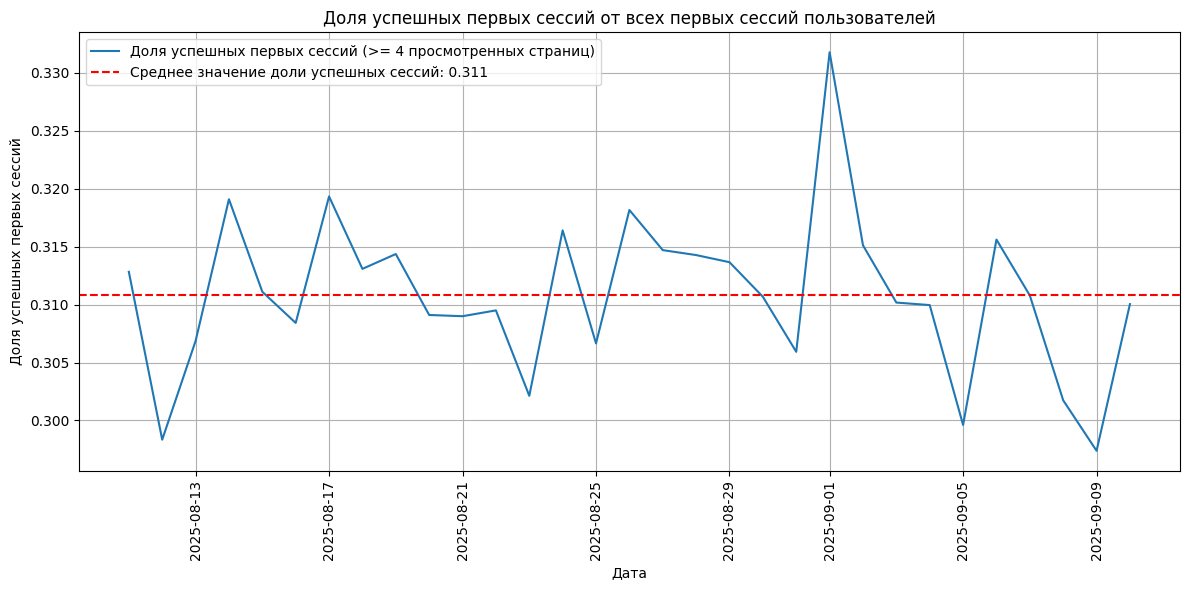

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Настройка основного графика доли успешных первых сессий
ax.plot(
    share_good_session.index,
    share_good_session.values,
    color="tab:blue",
    label="Доля успешных первых сессий (>= 4 просмотренных страниц)",
)
ax.set_xlabel("Дата")
ax.set_ylabel("Доля успешных первых сессий")
ax.set_title("Доля успешных первых сессий от всех первых сессий пользователей")
ax.tick_params(axis="x", labelrotation=90)

# Настройка линии среднего значения доли успешных сессий
share_good_session_mean = share_good_session.mean()
plt.axhline(
    y=share_good_session_mean,
    linestyle="--",
    color="red",
    label=f"Среднее значение доли успешных сессий: {share_good_session_mean.round(3)}",
)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Промежуточные выводы анализа ключевых метрик

- Пиковые значения числа уникальных пользователей и числа регистраций совпадают по дням наблюдения. Стоит проверить какие мероприятия проводились в эти дни (15.08, 22.08, 29.08, 05.09). Всегда пиковым днем недели выступает **пятница**.

- При этом доля зарегистрированных пользователей планомерно снижается с 4% до >1%. C 17 по 23 сентября регистраций не наблюдается.

- При первой сессии пользователи **чаще всего смотрят 2-4 страницы**

- В среднем **31% первых сессий** от общего числа первых сессий явлются успешными, то есть в этих первых сессиях пользователи просматривают 4 и более страниц. В среднем 69% первых сессий пользователи смотрят меньше 4 страниц соответственно. 


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки

Для расчет размера выборки установим в коде следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats.power`

In [16]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3  # Базовый уровень доли
mde = 0.3 * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1,  # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")
effect_size

Необходимый размер выборки для каждой группы: 41040


np.float64(-0.0195573929997348)

In [17]:
print(f"p          = {p!r}  ({type(p).__name__})")
print(f"mde        = {mde!r}  ({type(mde).__name__})")
print(f"effect_size = {effect_size!r}  ({type(effect_size).__name__})")

p          = 0.3  (float)
mde        = 0.009  (float)
effect_size = np.float64(-0.0195573929997348)  (float64)


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

In [18]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (
    (sessions_history.groupby("session_date")["user_id"].nunique()).mean().round()
)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей. Округляем до целого в большую сторону, так как нам нужно количество целых дней
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(
    f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней"
)

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.0 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Загрузим в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [19]:
sessions_test_part = pd.read_csv(
    "https://code.s3.yandex.net/datasets/sessions_project_test_part.csv"
)

Процентная разница в количестве пользователей в группах А и В составляет: 0.74%


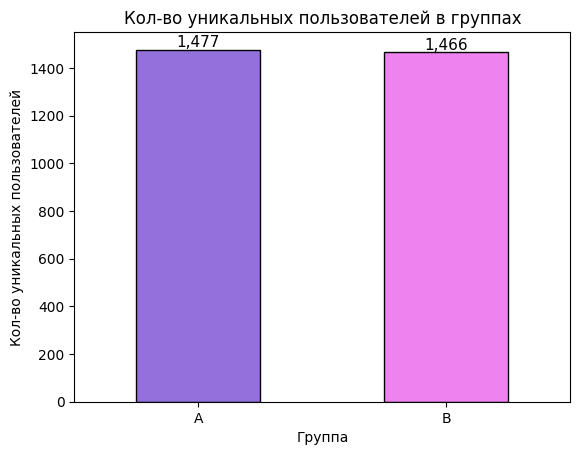

In [20]:
# Расчет и визуализация количества уникальных пользователей по группам А и В
test_part = sessions_test_part.groupby("test_group")["user_id"].nunique()

ax = test_part.plot(
    kind="bar", color=["mediumpurple", "violet"], edgecolor="black", rot=0
)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_xlabel("Группа")
ax.set_ylabel("Кол-во уникальных пользователей")
ax.set_title("Кол-во уникальных пользователей в группах")

print(
    f"Процентная разница в количестве пользователей в группах А и В составляет: {round((test_part.values[0] - test_part.values[1]) / test_part.values[0] * 100, 2)}%"
)

#### 3.2. Проверка пересечений пользователей

Проверим предположение о том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [21]:
test_a = sessions_test_part[sessions_test_part["test_group"] == "A"]["user_id"]
test_b = sessions_test_part[sessions_test_part["test_group"] == "B"]["user_id"]

# Проверка на пользователей, которые попали в обе группы
list(set(test_a) & set(test_b))

[]

**Контрольная (А) и тестовая (В) независимы** - ни один пользователь не попал в обе группы.

#### 3.3. Равномерность разделения пользователей по устройствам

Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

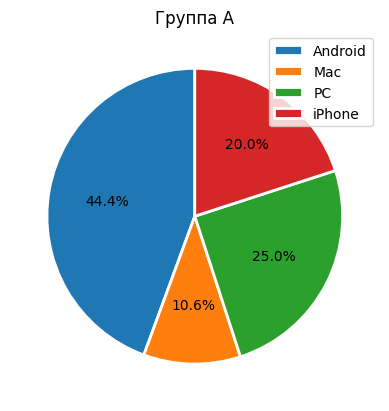

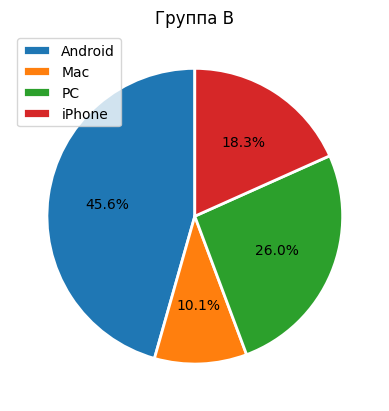

In [22]:
# Количество уникальных пользователей по группам и устройству
users_by_group_device = sessions_test_part.groupby(["test_group", "device"])[
    "user_id"
].nunique()

# Доля каждого типа устройств в группе А и В
share_device = (
    (
        users_by_group_device
        / users_by_group_device.groupby("test_group").transform("sum")
    )
    .round(3)
    .reset_index()
)

# Визуализация распределения устройств внутри групп А и В
for group in share_device["test_group"].unique():
    subset = share_device[share_device["test_group"] == group]
    subset.plot(
        kind="pie",
        y="user_id",
        labels=subset["device"],
        ylabel="",
        legend=True,
        startangle=90,
        autopct="%1.1f%%",
        labeldistance=None,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        title=f"Группа {group}",
    )

    plt.show()

Между группами А и B распределение уникальных пользователей по устройствам практически одинаково. Это означает, что рандомизация прошла успешно.

#### 3.4. Равномерность распределения пользователей по регионам

Убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

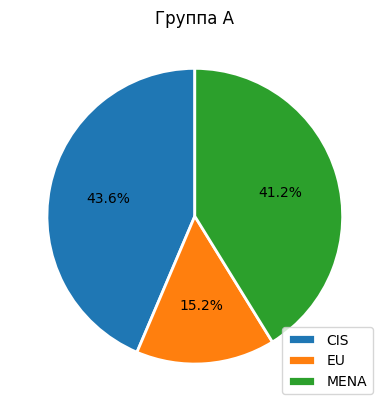

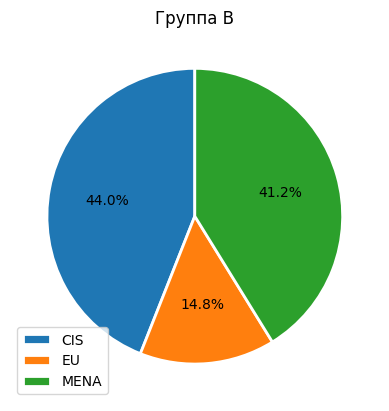

In [23]:
# Количество уникальных пользователей по группам и региону
users_by_group_region = sessions_test_part.groupby(["test_group", "region"])[
    "user_id"
].nunique()

# Доля каждого региона в группе А и В
share_region = (
    (
        users_by_group_region
        / users_by_group_region.groupby("test_group").transform("sum")
    )
    .round(3)
    .reset_index()
)

# Визуализация распределения регионов внутри групп А и В
for group in share_region["test_group"].unique():
    subset = share_region[share_region["test_group"] == group]
    subset.plot(
        kind="pie",
        y="user_id",
        labels=subset["region"],
        ylabel="",
        legend=True,
        startangle=90,
        autopct="%1.1f%%",
        labeldistance=None,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        title=f"Группа {group}",
    )

    plt.show()

Также как и по устройствам, распределение пользователей по регионам в между группами теста - практически одинаково.

#### 3.5. Вывод после проверки A/B-теста

После проверки первых 3 дней A/B-теста можно сказать, что тест проходит успешно. 

- Не было выявлено значительной разницы между группами А и В по количеству уникальных пользователей (1477 vs 1466), разница в процентах - 0.74%.
- Можно сказать, что выборки независимы, так как не было обнаружено пересечения пользователей из контрольной и тестовой групп.
- Между группами сохраняется равномерное распределение по категориальным признакам: устройствам и регионам.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [24]:
session_test = pd.read_csv(
    "https://code.s3.yandex.net/datasets/sessions_project_test.csv"
)

In [25]:
session_test["good_session"] = (session_test["page_counter"] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

**Контекст эксперимента**. Тестируются две группы пользователей: контрольная группа A (действующая рекомендательная система) и тестовая группа B (новая рекомендательная система). Пользователи распределены между группами случайно, что обеспечивает сопоставимость групп.

**Целевая метрика**: Доля успешных первых сессий (`good_session = 1` если `page_counter >= 4`), критерий: $pB > pA$ (статистически значимо)

**Нулевая гипотеза (H₀)**: доля успешных первых сессий в группе с новым алгоритмом (B) не превышает (меньше или равно) долю успешных первых сессий в контрольной группе (A):

$H0:pB = pA$
​

**Альтернативная односторонняя гипотеза (H₁)**: доля успешных первых сессий в группе с новым алгоритмом (B) статистически значимо выше, чем в контрольной группе (А):


$H1: pB > pA$
​

**Тип теста**: односторонний, так как ожидаем только улучшение от нового алгоритма.

За **прокси-метрику** можно принять долю пользователей, которые взаимодействуют с новым блоком рекомендаций. При условии, что блок рекомендаций не показывается автоматически и на него пользователь можно перейти самостоятельно (Доля в B ≥ A). 

- Прокси метрика (вариант 2): Средняя глубина просмотра (первые сессии), критерий: Среднее значение в B ≥ A.
- Прокси метрика (вариант 3): Доля первых сессий с ≥2 страниц, критерий: Доля в B ≥ A.

За **барьерную метрику** можно принять несколько вариантов:

- Конверсия в регистрацию, критерий: Доля зарегистрированных новых пользователей не должна снижаться более чем на X%.
- вариант при наличии данных: Доля сессий с негативной реакцией на рекламу, критерий: Не должна расти.
- вариант при наличии данных: ARPU (доход на пользователя), критерий: Не должен снижаться.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используя созданный столбец `good_session`, рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [26]:
good_session = (
    session_test[session_test["session_number"] == 1]
    .groupby("test_group")["good_session"]
    .sum()
)

session = (
    session_test[session_test["session_number"] == 1]
    .groupby("test_group")["session_number"]
    .sum()
)

good_session_share = round(good_session / session, 4)

print(f"Доля успешных первых сессий в группе А: {good_session_share.values[0]}")
print(f"Доля успешных первых сессий в группе B: {good_session_share.values[1]}")
print(
    f"Относительная процентная разница метрики между группами: {round((good_session_share.values[1] - good_session_share.values[0]) / good_session_share.values[1] * 100, 2)}%"
)
print(
    f"Абсолютная разница метрики между группами: {round((good_session_share.values[1] - good_session_share.values[0])*100, 2)} п.п"
)

Доля успешных первых сессий в группе А: 0.3157
Доля успешных первых сессий в группе B: 0.3147
Относительная процентная разница метрики между группами: -0.32%
Абсолютная разница метрики между группами: -0.1 п.п


#### 4.4. Насколько статистически значимо изменение ключевой метрики

Доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используем статистический тест z-тест пропорций, так как метрика является долевой. Рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

In [27]:
alpha = 0.05  # Уровень значимости

# Размеры выборок групп
n_a = session_test[
    (session_test["test_group"] == "A") & (session_test["session_number"] == 1)
].shape[0]

n_b = session_test[
    (session_test["test_group"] == "B") & (session_test["session_number"] == 1)
].shape[0]

# Доля успехов (успешных первых сессий) в группах
m_a = session_test[
    (session_test["test_group"] == "A")
    & (session_test["session_number"] == 1)
    & (session_test["good_session"] == 1)
].shape[0]

m_b = session_test[
    (session_test["test_group"] == "B")
    & (session_test["session_number"] == 1)
    & (session_test["good_session"] == 1)
].shape[0]

# Доля успехов в группах
p_a, p_b = m_a / n_a, m_b / n_b


print(f"Размер выборки группы А = {n_a}, B = {n_b}")
print(f"Количество успехов (успешных сессий) группы А = {m_a}, B = {m_b}")
print(f"Доля успехов группы А = {p_a}, B = {p_b}")

Размер выборки группы А = 15162, B = 15416
Количество успехов (успешных сессий) группы А = 4787, B = 4851
Доля успехов группы А = 0.31572351932462733, B = 0.3146730669434354


In [28]:
# Проверка предпосылки о достаточном количестве данных в выборках
if (
    (p_a * n_a > 10)
    and ((1 - p_a) * n_a > 10)
    and (p_b * n_b > 10)
    and ((1 - p_b) * n_b > 10)
):
    print("Предпосылка о достаточном количестве данных выполняется")
else:
    print("Предпосылка о достаточном количестве данных НЕ выполняется")

Предпосылка о достаточном количестве данных выполняется


In [29]:
from statsmodels.stats.proportion import proportions_ztest

# Проведение z-теста пропорций
stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a], [n_b, n_a], alternative="larger"  # Проверяем гипотезу pB > pA
)

if p_value_ztest > alpha:
    print(f"pvalue = {p_value_ztest} > {alpha}")
    print(
        "Недостаточно оснований отклонить H0. Нет оснований считать, что группы А и B различаются "
    )
else:
    print(f"pvalue = {p_value_ztest} < {alpha}")
    print(
        "Альтернативная гипотеза находит подтверждение, доля успешных сессий статистически выше в группе В"
    )

pvalue = 0.5783523649187868 > 0.05
Недостаточно оснований отклонить H0. Нет оснований считать, что группы А и B различаются 


#### 4.5 Расчет и проверка статистической значимости прокси-метрик

In [30]:
# Прокси: средняя глубина просмотра в первых сессиях
proxy_depth = (
    session_test[session_test["session_number"] == 1]
    .groupby("test_group")["page_counter"]
    .mean()
)

proxy_depth

test_group
A    3.017412
B    3.030034
Name: page_counter, dtype: float64

Средняя глубина просмотра в первых сессиях в тестовой группе с новым алгоритмом (B) выше, чем в контрольной группе со старым алгоритмом (А).

Для проверки статистической значимости этого результата используем двухвыборочный односторонний t-test Уэлча, так как мы сравниваем выборочные средние значения. Также это безопаснее, если дисперсии групп различаются.  

In [31]:
# Проверка статистической значимости средней глубины просмотра первых сессий
# H0 = muA = muB
# H1 = muB > muA

proxy_depth_a = session_test[
    (session_test["session_number"] == 1) & (session_test["test_group"] == "A")
]["page_counter"]
proxy_depth_b = session_test[
    (session_test["session_number"] == 1) & (session_test["test_group"] == "B")
]["page_counter"]

ttest_result = ttest_ind(
    proxy_depth_b, proxy_depth_a, alternative="greater", equal_var=False
)

if ttest_result.pvalue > alpha:
    print(f"{ttest_result.pvalue} > {alpha}")
    print(
        "Нулевая гипотеза не отвергается, между группами А и В нет значимых различий в глубине просмотра первых сессий"
    )
else:
    print(f"{ttest_result.pvalue} < {alpha}")
    print(
        "Нулевая гипотеза отвергается, в группе В среднее значение глубины просмотра статистически выше, чем в группе А"
    )

0.1452619173131259 > 0.05
Нулевая гипотеза не отвергается, между группами А и В нет значимых различий в глубине просмотра первых сессий


In [32]:
# Прокси: доля сессий с ≥2 страниц
first_session_2plus = session_test[session_test["session_number"] == 1].assign(
    has_2plus=lambda d: d["page_counter"] >= 2
)

agg = first_session_2plus.groupby("test_group")["has_2plus"].agg(
    success="sum",  # число сессий с ≥2 страниц
    total="size",  # всего первых сессий в группе
)

count = agg["success"].values  # [success_A, success_B]
nobs = agg["total"].values  # [total_A, total_B]


# Проверка статистической значимости доли первых сессий с >= 2 просмотренными страницами
# H0 = pA = pB
# H1 = pB > pA
stat, p_value = proportions_ztest(
    [count[1], count[0]],  # count[1] = B, count[0] = A
    [nobs[1], nobs[0]],  # nobs[1] = B, nobs[0] = A
    alternative="larger",  # односторонняя: доля в B > доли в A
)

print(f"p-value: {p_value:.4f}")

if p_value > alpha:
    print(f"{p_value} > {alpha}")
    print(
        "Нулевая гипотеза не отвергается. Нет оснований считать, что доли сессий с просмотром >= 2 страниц различаются в группах А и B"
    )
else:
    print(f"{p_value} < {alpha}")
    print(
        "Нулевая гипотеза отвергается, в группе В доля сессий с просмотром >= 2 страниц статистически выше, чем в группе А"
    )

p-value: 0.2248
0.22484550629779726 > 0.05
Нулевая гипотеза не отвергается. Нет оснований считать, что доли сессий с просмотром >= 2 страниц различаются в группах А и B


#### Проверка соответствия размера выборки

In [33]:
print("Фактический размер выборки набранный за 20 дней эксперимента на каждую группу:")
session_test.groupby("test_group")["user_id"].nunique()

Фактический размер выборки набранный за 20 дней эксперимента на каждую группу:


test_group
A    15163
B    15416
Name: user_id, dtype: int64

In [34]:
effect_size = abs(proportion_effectsize(p, p + mde))
power_analysis = NormalIndPower()

actual_power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=15163,  # фактический размер одной группы
    alpha=0.05,
    ratio=1,
    power=None,
    alternative="larger",  # alternative="larger", так мы проверяем односторонюю гипотезу
)
print(f"Фактическая мощность для одностороннего теста: {actual_power:.2%}")

Фактическая мощность для одностороннего теста: 52.31%


In [59]:
from scipy.stats import norm

norm.ppf(0.95)

np.float64(1.6448536269514722)

In [ ]:
from math import sqrt

p = 0.3
n = 15163
z_alpha_one_sided = 1.645
z_beta = 0.84

mde_one_sided = (z_alpha_one_sided + z_beta) * sqrt(2 * p * (1 - p) / n)
print(
    f"Реальный MDE (односторонний), который тест может детектировать: {mde_one_sided:.4f} = {mde_one_sided*100:.2f} п.п."
)

Реальный MDE (односторонний), который тест может детектировать: 0.0131 = 1.31 п.п.


In [62]:
mde_target = 0.009

n_needed = 2 * p * (1 - p) * ((z_alpha_one_sided + z_beta) / mde_target) ** 2

print(
    f"Нужно на группу при предполагаемом MDE {mde_target}% ({round(mde_target*100, 1)} п.п): {int(n_needed)}"
)

Нужно на группу при предполагаемом MDE 0.009% (0.9 п.п): 32019


#### 4.5. Вывод по результатам A/B-эксперимента

**Результаты по целевой метрике**. За весь период теста доля успешных первых сессий составила:

- группа A: 31.57%;
- группа B: 31.47%;
- абсолютная разница: −0.10 п.п. (B незначительно ниже A);
- относительная разница: −0.32%.

Односторонний z-тест пропорций ($H₁: p_B > p_A$) дал $pvalue$ = 0.578, что существенно выше уровня значимости $α$ = 0.05. Статистически значимого роста целевой метрики в группе B не обнаружено. Более того, наблюдаемая разница между группами направлена против альтернативной гипотезы, что дополнительно указывает на отсутствие положительного эффекта.

**Результаты по прокси-метрикам.**

Прокси-метрика 1 — средняя глубина просмотра первых сессий (page_counter):
- группа A: 3.0174;
- группа B: 3.0300%;
- Разница +0.0126 (B выше на ~0.4%)

Односторонний t-тест $(H₁: μ_B > μ_A)$ дал $pvalue$ = 0.145 > $α$ = 0.05. Статистически значимого роста глубины просмотра в группе B не зафиксировано.

Прокси-метрика 2 — доля первых сессий с ≥ 2 просмотренными страницами:

- Односторонний z-тест пропорций $(H₁: p_B > p_A)$ дал $pvalue ≈ 0.225 > α = 0.05$. Статистически значимого превышения доли в группе B относительно группы A нет.

**Интерпретация по прокси-метрикам**. Ни одна из двух прокси-метрик не показала значимого улучшения в тестовой группе. Направление изменений формально положительное (B чуть лучше A), но величина эффекта мала и не выходит за пределы случайных колебаний. Это согласуется с результатом по целевой метрике: **признаков влияния новой рекомендательной системы на поведение пользователей в первых сессиях не обнаружено.**

**Ограничение по мощности теста.** Изначально для детекции $MDE$ = 0.9 п.п. при alpha = 0.05 и power = 0.8 требовалось 41 040 уникальных пользователей на группу. Фактически за 20 дней теста набрано 15 163 и 15 416 пользователей в группах A и B соответственно, что дало фактическую мощность (при одностороннем тесте) 52.81%. При таком объёме тест способен детектировать только эффект ≥ 1.3 п.п., что в 1.46 раза больше целевого $MDE$ (0.9 п.п). 

Следовательно, тест недостаточно мощный: результат $pvalue$ = 0.578 > 0.05 в данном случае говорит о том, что у нас пока недостаточно данных, чтобы отклонить нулевую гипотезу.

Для корректного вывода <u>без увеличения длителности</u> и <u>без повышения стоимости эксперимента</u> **стоит увеличить долю трафика** (новых пользователей в день) и возможно **использовать более чувствительную метрику**.

В крайнем случае, требуется либо **продление теста** до набора ~32019 пользователей на группу, либо **пересмотр MDE в сторону увеличения**, например, до 1.5 п.п., который тест при текущем объёме данных способен детектировать с мощностью 80%.

**Внедрение новой рекомендательной системы по результатам текущего теста не обосновано**. Решение о раскатке фичи следует принимать после повторного теста с достаточной мощностью.